In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from scipy.stats import chi2
import scipy.stats
import matplotlib.lines as mlines

Text(0, 0.5, 'Observed -log$_{10}$($\\itP$)')

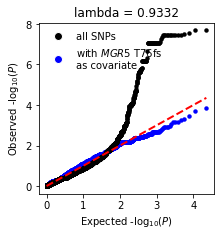

In [7]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)

def observed(dataframe):
    df=dataframe['P'].to_numpy()
    df=np.sort(df)
    return(df)

def expected(dataframe):
    df=np.linspace(1, 1/(dataframe.shape[0]),dataframe.shape[0])
    df=-np.log10(df)
    df=np.sort(df)
    return(df)

classic=parse('Mg24_miss10.assoc.txt')
classic_observed=observed(classic)
classic_expected=expected(classic)

MGR5_76fs=parse('Mg24_miss10_cov.assoc.txt')
MGR5_76fs_observed=observed(MGR5_76fs)
MGR5_76fs_expected=expected(MGR5_76fs)

cm = 1/2.54
fig = plt.figure(figsize=(8*cm,8*cm))
ax = sns.scatterplot(x=classic_expected,
                y=classic_observed,
                marker='o',
                s=20,
                color='k',
                linewidth=0,
                zorder=5)
ax = sns.scatterplot(x=MGR5_76fs_expected,
                y=MGR5_76fs_observed,
                marker='o',
                color='b',
                s=20,
                linewidth=0,
                zorder=4)

ax = sns.lineplot(x=classic_expected,
                y=classic_expected,
                color='r',
                linestyle='--',
                linewidth=2,
                zorder=6)

legend_elements = [mlines.Line2D([0], [0],color='w', marker='o',markerfacecolor='k',
                          markersize=8, label='all SNPs'),
                   mlines.Line2D([0], [0],color='w', marker='o',markerfacecolor='b',
                          markersize=8, label='with $\itMGR5$ T76fs\nas covariate')]
                

ax.legend(handles=legend_elements,loc='best',frameon=False)
Lambda=chi2.ppf(1 - np.median(classic['p_lrt']), 1)/chi2.ppf(0.5, 1)
ax.set_title('lambda = {:.4f}'.format(Lambda))
ax.set_xlabel('Expected -log$_{10}$($\itP$)',fontsize=10)
ax.set_ylabel('Observed -log$_{10}$($\itP$)',fontsize=10)
# plt.savefig("FigS9b.pdf", format="pdf",bbox_inches="tight",facecolor="w")